In [1]:
!pip install lime

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.0 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.0 MB 4.4 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.0 MB 4.9 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.0 MB 5.6 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.0 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/12.0 MB 6.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 6.1 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pickle
import numpy as np
from lime.lime_text import LimeTextExplainer

In [3]:
with open("../models/final_pipeline.pkl", "rb") as f:
    pipeline = pickle.load(f)

print("Pipeline Loaded Successfully!")

Pipeline Loaded Successfully!


In [4]:
print(pipeline.classes_)

['Excellent' 'Neutral' 'Not Good' 'Poor' 'Very Good']


In [5]:
explainer = LimeTextExplainer(
    class_names=pipeline.classes_,
    random_state=42
)

print("LIME Explainer Created!")

LIME Explainer Created!


In [6]:
comment = "Movie super bagundi"

print("Comment:", comment)

prediction = pipeline.predict([comment])[0]
probabilities = pipeline.predict_proba([comment])[0]

print("Prediction:", prediction)

print("\nProbabilities")

for cls, prob in zip(pipeline.classes_, probabilities):
    print(f"{cls:12}: {prob:.4f}")

Comment: Movie super bagundi
Prediction: Very Good

Probabilities
Excellent   : 0.0034
Neutral     : 0.0353
Not Good    : 0.0004
Poor        : 0.0002
Very Good   : 0.9606


In [7]:
exp = explainer.explain_instance(
    text_instance=comment,
    classifier_fn=pipeline.predict_proba,
    num_features=10,
    top_labels=1
)

print("Explanation Generated Successfully!")

Explanation Generated Successfully!


In [9]:
print(exp.available_labels())

[np.int64(4)]


In [10]:
label = exp.available_labels()[0]
print(exp.as_list(label=label))

[(np.str_('super'), 0.4614700892085947), (np.str_('Movie'), 0.047820674362653706), (np.str_('bagundi'), -0.01410276391648172)]


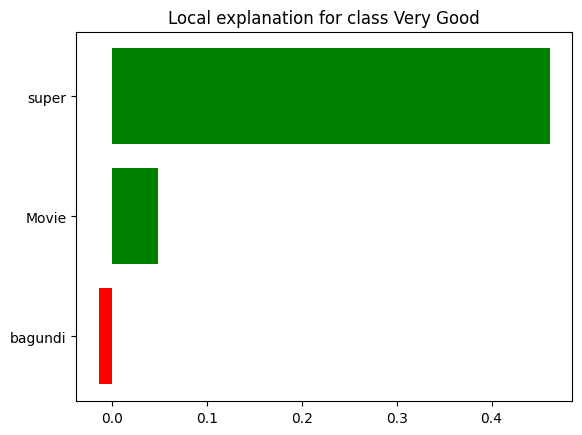

In [11]:
label = exp.available_labels()[0]
fig = exp.as_pyplot_figure(label=label)

In [12]:
print(exp.as_list(label=4))

[(np.str_('super'), 0.4614700892085947), (np.str_('Movie'), 0.047820674362653706), (np.str_('bagundi'), -0.01410276391648172)]
